# Definitions

In [1]:
%matplotlib inline
import sys, platform, os
# threads of cosmolike's OpenMP regions; a value already set in the shell wins
os.environ.setdefault('OMP_NUM_THREADS', '4')
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import cosmolike_des_cluster_interface as ci
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 15
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# Resolution of the inline figures. The notebook is committed with its
# outputs, so a moderate value keeps the file at a few MB; for sharper
# figures on screen raise it, or add the line
# %config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.dpi'] = 80
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# BE CAREFUL: you need texlive-latex-base texlive-latex-extra texlive-fonts-recommended dvipng ghostscript cm-super
matplotlib.rcParams['text.usetex'] = True
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))

3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/des_cluster


In [2]:
# IMPORT CAMB
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

# IMPORT SHARED NOTEBOOK UTILITIES (cosmolike_core)
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/cosmolike_core')
import cosmolike_notebook_utils as cnu
print('Using cosmolike_notebook_utils installed at %s'%(os.path.dirname(cnu.__file__)))
# the cluster data-vector plots live in their own module of that package
# (it is not part of the cnu.* namespace): call them as pdc.plot_N_cluster,
# pdc.plot_sigma_cluster_tomo, pdc.plot_wcc_tomo, pdc.plot_wcg_tomo, ...
from cosmolike_notebook_utils import plot_datavectors_cluster as pdc

# IMPORT THE PROJECT'S NOTEBOOK WRAPPERS (projects/des_cluster/interface):
# the cluster observables, the halo-model ingredients, and the chi2
# wrappers every notebook of this project shares
import cosmolike_des_cluster_notebook_wrappers as nw
print('Using notebook wrappers installed at %s'%(nw.__file__))

Using CAMB 1.6.7 installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/.local/lib/python3.11/site-packages/camb


Using cosmolike_notebook_utils installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/external_modules/code/cosmolike_core/cosmolike_notebook_utils
Using notebook wrappers installed at /Users/vivianmiranda/data/COCOA/september2026/test/cocoa/Cocoa/projects/des_cluster/interface/cosmolike_des_cluster_notebook_wrappers.py


In [3]:
# The options of EXAMPLE_EVALUATE1.yaml: CL+GC (4x2pt + N) on the synthetic
# DES Y6-like data = cluster counts, cluster lensing, w_cc, w_cg and the
# galaxy clustering of MagLim bins 1-3. For CL+3x2pt (EXAMPLE_EVALUATE2.yaml)
# set CLprobe = "6x2pt_N" and data_file = "des_cluster_y6_6x2ptN.dataset"
CLprobe = "4x2pt_N"

path = "../../external_modules/data/des_cluster"
data_file = "des_cluster_y6_4x2ptN.dataset"

non_linear_emul = 2
IA_model = 0
IA_redshift_evolution = 3
IA_code = 0  # 0 = C FASTPT, 1 = Python FAST-PT (NLA always uses 0)
lmax = 75000
integration_accuracy = 1

cluster_kernel_mode = 0       # 0 = volume only (what DES ran), 1 = abundance weighted
cluster_selection_model = 2   # 0 = none, 1 = Y1 (mass dependent), 2 = Y6 (scale dependent, eq 23)
cluster_ytransform = 1        # 1 = Sigma = Y gamma_t (eq 15), 0 = gamma_t
cluster_include_ia = 1
cluster_magnification = -2.0  # C_c (eq 28)
cluster_hmf_alpha_mode = 0    # 0 = Tinker alpha = 0.368 at every z (what DES ran)

# hand this notebook's yaml-mirroring values to the shared wrappers
nw.configure(path=path,
             data_file=data_file,
             lmax=lmax,
             integration_accuracy=integration_accuracy,
             non_linear_emul=non_linear_emul,
             IA_model=IA_model,
             IA_redshift_evolution=IA_redshift_evolution,
             IA_code=IA_code,
             cluster_kernel_mode=cluster_kernel_mode,
             cluster_selection_model=cluster_selection_model,
             cluster_ytransform=cluster_ytransform,
             cluster_include_ia=cluster_include_ia,
             cluster_magnification=cluster_magnification,
             cluster_hmf_alpha_mode=cluster_hmf_alpha_mode)

In [4]:
# The project fiducial point lives in the wrappers module
# (interface/cosmolike_des_cluster_notebook_wrappers.py): Table I of
# arXiv 2503.13631, the point of the synthetic data vector
# (scripts/make_synthetic_data.py). Override any value per call
# instead, e.g. nw.N_cluster(omegam=0.31) or nw.N_cluster(MOR=[...]).
from cosmolike_des_cluster_notebook_wrappers import (
    As_1e9, ns, H0, omegab, omegam, mnu, w, w0pwa,
    DES_CL_LNLAMBDA0, DES_CL_A_LAMBDA, DES_CL_SIGMA_INT, DES_CL_B_LAMBDA,
    DES_CL_BS1, DES_CL_BS2, DES_CL_R0, DES_CL_BSZ)
print("cosmology: As_1e9 = %g, ns = %g, H0 = %g, omegab = %g, omegam = %g, mnu = %.5f eV, w = %g"
      %(As_1e9, ns, H0, omegab, omegam, mnu, w))
print("mass-observable relation (ln lambda_0, A_lambda, sigma_int, B_lambda):", nw.MOR_FID)
print("selection bias (b_s1, b_s2, r_0 [Mpc/h], s3):", nw.SELECTION_FID)

cosmology: As_1e9 = 2.19, ns = 0.96859, H0 = 69, omegab = 0.048, omegam = 0.3, mnu = 0.07719 eV, w = -1
mass-observable relation (ln lambda_0, A_lambda, sigma_int, B_lambda): [4.26, 0.943, 0.15, 0.207]
selection bias (b_s1, b_s2, r_0 [Mpc/h], s3): [1.1, 0.2, 30.0, 0.0]


In [5]:
# Init Cosmolike (the full sequence lives in nw.init_cosmolike: the init
# chain of the likelihood, likelihood/_cosmolike_prototype_base.py).
# with_data = True also loads the mask, the synthetic data vector and its
# covariance (the data overlays and the chi2 below need them)
ini = nw.init_cosmolike(CLprobe=CLprobe, with_data=True)

# bins of the dataset
dataset = nw.dataset_info()
richness_edges = dataset["richness_edges"]
zbin_edges = dataset["cluster_zbin_edges"]
nrichness = len(richness_edges) - 1
ncluster = len(zbin_edges) - 1
nsource = dataset["source_ntomo"]
nlens = dataset["lens_ntomo"]
richness_label = [r"$\lambda \in [%g, %g)$"%(richness_edges[i], richness_edges[i+1]) for i in range(nrichness)]
zbin_label = [r"$z_\lambda \in [%g, %g)$"%(zbin_edges[i], zbin_edges[i+1]) for i in range(ncluster)]
richness_color = plt.get_cmap("viridis")(np.linspace(0.0, 0.85, nrichness))
zbin_color = plt.get_cmap("plasma")(np.linspace(0.1, 0.75, ncluster))
print("richness bins:", richness_edges, " cluster z bins:", zbin_edges)
print("source bins:", nsource, " lens bins:", nlens, " survey area [deg2]:", dataset["survey_area_deg2"])
# (cluster z bin, lens bin) pairs of w_cg
print("w_cg pairs (cluster z bin, lens bin):", np.array(ci.get_cg_redshift_bins()).astype(int).tolist())

richness bins: [ 20.  30.  45.  60. 500.]  cluster z bins: [0.2  0.4  0.55 0.65]
source bins: 4  lens bins: 6  survey area [deg2]: 4143.0
w_cg pairs (cluster z bin, lens bin): [[0, 0], [1, 1], [2, 2]]


In [6]:
# The joint data vector (ss, gs, gg, cg, N, cc, cs) of the dataset: the
# synthetic data, its 1-sigma errors, and the mask, in the full layout
dv_names = ["ss", "gs", "gg", "cg", "N", "cc", "cs"]
dv_sizes = np.array(ci.compute_data_vector_cluster_sizes())
dv_starts = np.array(ci.compute_data_vector_cluster_starts())
dv_block = {name: slice(dv_starts[i], dv_starts[i] + dv_sizes[i]) for i, name in enumerate(dv_names)}
dv_mask = np.array(ci.get_mask_cluster()).astype(bool)
for name in dv_names:
    print("%2s: %4d entries, %4d after the scale cuts"%(name, dv_sizes[dv_names.index(name)], dv_mask[dv_block[name]].sum()))

# The cluster blocks of the data and of their 1-sigma errors, put back
# into the array layouts of the model wrappers (N: [richness, cluster z],
# cs: [theta, richness, cluster z, source], cc: [theta, richness 1,
# richness 2, cluster z], cg: [theta, richness, cluster z, lens]).
# Entries the scale cuts remove are NaN: the plotting functions skip them
data, error = nw.data_cluster_blocks()

ss:  400 entries,    0 after the scale cuts
gs:  480 entries,    0 after the scale cuts
gg:  120 entries,   31 after the scale cuts
cg:  240 entries,  128 after the scale cuts
 N:   12 entries,   12 after the scale cuts
cc:  600 entries,  230 after the scale cuts
cs:  960 entries,  488 after the scale cuts


# Cluster number counts $N$ per richness and redshift bin

In [7]:
# counts[richness bin, cluster z bin] (eq 16 of arXiv 2503.13631)
counts = nw.N_cluster()
print("expected counts (rows = richness bins, columns = cluster z bins):")
for nl in range(nrichness):
    print("  lambda in [%3g, %3g): "%(richness_edges[nl], richness_edges[nl+1]) + "  ".join("%9.2f"%x for x in counts[nl]))
print("  total per z bin:       " + "  ".join("%9.2f"%x for x in counts.sum(axis=0)))

expected counts (rows = richness bins, columns = cluster z bins):
  lambda in [ 20,  30):   3759.97    4552.95    3415.00
  lambda in [ 30,  45):   1683.21    1877.37    1314.80
  lambda in [ 45,  60):    541.19     551.64     358.28
  lambda in [ 60, 500):    440.97     387.19     223.71
  total per z bin:         6425.34    7369.15    5311.79


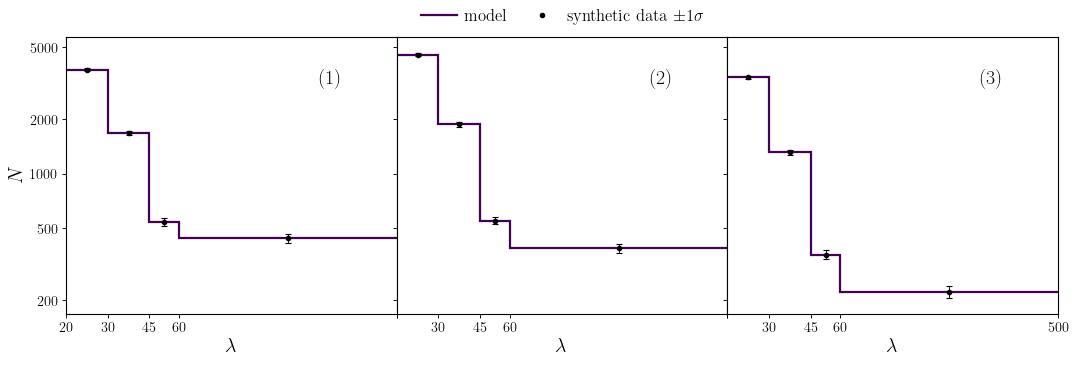

In [8]:
# model counts against the synthetic data: one panel per cluster z bin
# (the label in each panel), the richness on the x axis
pdc.plot_N_cluster(N = [counts],
                   richness_edges = richness_edges,
                   data = (data["N"], error["N"]),
                   datalabel = r"synthetic data $\pm 1\sigma$",
                   legend = ["model"],
                   cmap = "viridis",
                   linewidth = [2.0],
                   figsize = (16, 4.5),
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

# Halo-model ingredients: $P(\lambda\,{\rm bin}|M,z)$, $n_{\rm cl}(z)$, $b_{\rm cl}(z)$

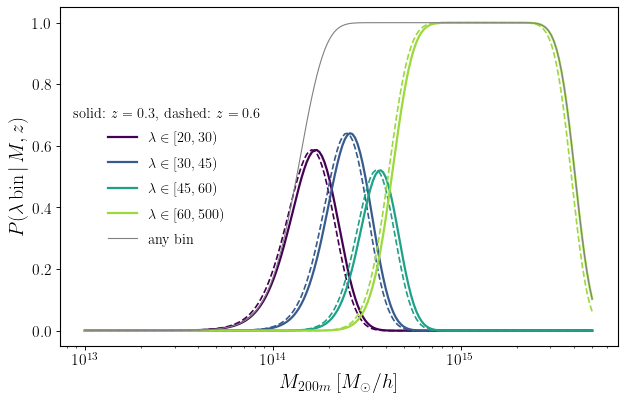

In [9]:
# Probability that a halo of mass M lands in each richness bin: the
# lognormal mass-observable relation of eqs (18)-(19)
M = np.logspace(13.0, 15.7, 200)   # Msun/h (M200m)
z_P = np.array([0.3, 0.6])
P = nw.prob_richness_bin_given_m(M, z_P)   # (n_M, n_z, n_richness)

fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
for nl in range(nrichness):
    ax.plot(M, P[:, 0, nl], color=richness_color[nl], linewidth=2.0, label=richness_label[nl])
    ax.plot(M, P[:, 1, nl], color=richness_color[nl], linewidth=1.5, linestyle="dashed")
ax.plot(M, P[:, 0, :].sum(axis=1), color="gray", linewidth=1.0, label="any bin")
ax.set_xscale("log")
ax.set_xlabel(r"$M_{200m}\ [M_\odot/h]$", fontsize=18)
ax.set_ylabel(r"$P(\lambda\,{\rm bin}\,|\,M, z)$", fontsize=18)
ax.tick_params(labelsize=14)
ax.legend(loc="center left", fontsize=13, frameon=False, title=r"solid: $z = %g$, dashed: $z = %g$"%tuple(z_P), title_fontsize=13)
plt.show()

n_cl and b_cl tabulated for z in [0.158, 0.708]


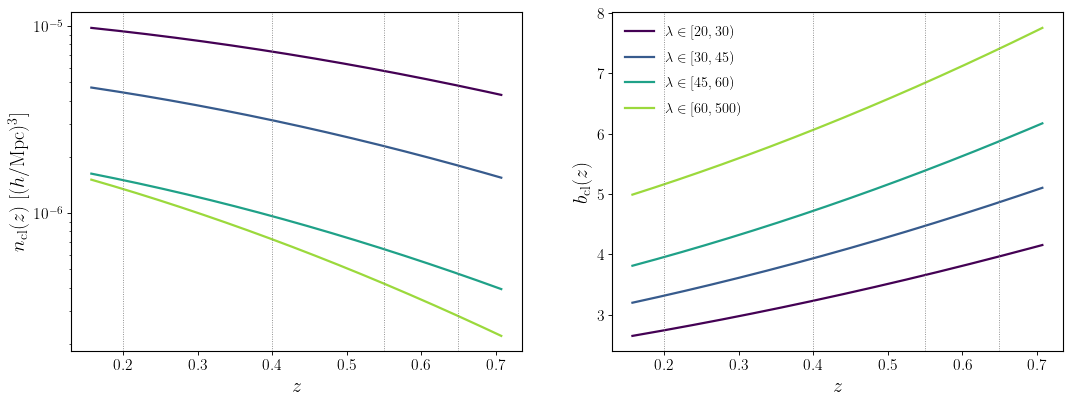

In [10]:
# Number density and bias of the clusters of each richness bin. The tables
# of the C code cover the redshift support of the cluster bins and return
# zero outside it, so the curves are drawn where n_cl > 0.
z = np.linspace(0.1, 0.8, 281)
ncl = nw.ncl_richness(z)   # (n_z, n_richness) in (h/Mpc)^3
bcl = nw.bcl_richness(z)   # (n_z, n_richness)
inside = ncl[:, 0] > 0
print("n_cl and b_cl tabulated for z in [%.3f, %.3f]"%(z[inside].min(), z[inside].max()))

fig, axs = plt.subplots(1, 2, figsize=(16, 5.5))
for nl in range(nrichness):
    axs[0].plot(z[inside], ncl[inside, nl], color=richness_color[nl], linewidth=2.0, label=richness_label[nl])
    axs[1].plot(z[inside], bcl[inside, nl], color=richness_color[nl], linewidth=2.0, label=richness_label[nl])
axs[0].set_yscale("log")
axs[0].set_ylabel(r"$n_{\rm cl}(z)\ [(h/{\rm Mpc})^3]$", fontsize=18)
axs[1].set_ylabel(r"$b_{\rm cl}(z)$", fontsize=18)
for ax in axs:
    for edge in zbin_edges:
        ax.axvline(edge, color="gray", linewidth=0.8, linestyle="dotted")
    ax.set_xlabel(r"$z$", fontsize=18)
    ax.tick_params(labelsize=14)
axs[1].legend(loc="upper left", fontsize=13, frameon=False)
plt.show()

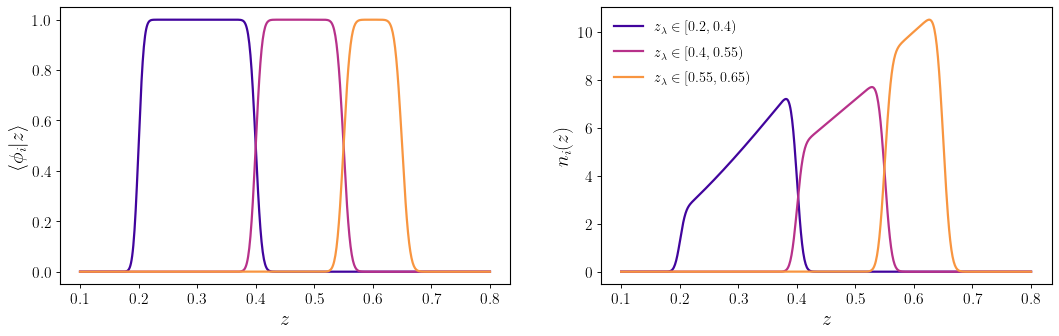

In [11]:
# Redshift selection of the cluster bins: the kernels <phi_i|z> (the
# probability that a cluster at true redshift z lands in z_lambda bin i)
# and the normalized true-redshift distributions n_i(z) ~ dV/dz <phi_i|z>
z = np.linspace(0.1, 0.8, 701)
phi = nw.phi_cluster(z)   # (n_z, n_cluster)
nz = nw.nz_cluster(z)     # (n_z, n_cluster, n_richness); volume kernel: the same for every richness bin

fig, axs = plt.subplots(1, 2, figsize=(16, 4.5))
for ni in range(ncluster):
    axs[0].plot(z, phi[:, ni], color=zbin_color[ni], linewidth=2.0, label=zbin_label[ni])
    axs[1].plot(z, nz[:, ni, 0], color=zbin_color[ni], linewidth=2.0, label=zbin_label[ni])
axs[0].set_ylabel(r"$\langle \phi_i | z \rangle$", fontsize=18)
axs[1].set_ylabel(r"$n_i(z)$", fontsize=18)
for ax in axs:
    ax.set_xlabel(r"$z$", fontsize=18)
    ax.tick_params(labelsize=14)
axs[1].legend(loc="upper left", fontsize=13, frameon=False)
plt.show()

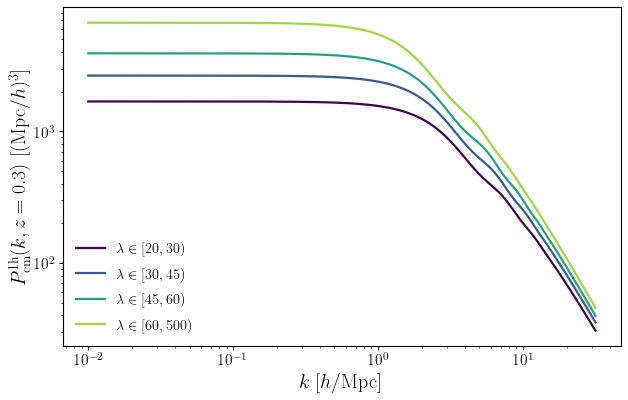

In [12]:
# One-halo cluster-matter power spectrum of each richness bin (eq 22): the
# NFW profile of the clusters' own halos, the small-scale part of cluster lensing
k = np.logspace(-2, 1.5, 200)   # h/Mpc
p1h = nw.pcm_1h_richness(k, [0.3])   # (n_k, n_z, n_richness) in (Mpc/h)^3

fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
for nl in range(nrichness):
    ax.plot(k, p1h[:, 0, nl], color=richness_color[nl], linewidth=2.0, label=richness_label[nl])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$k\ [h/{\rm Mpc}]$", fontsize=18)
ax.set_ylabel(r"$P^{\rm 1h}_{\rm cm}(k, z = 0.3)\ [({\rm Mpc}/h)^3]$", fontsize=18)
ax.tick_params(labelsize=14)
ax.legend(loc="lower left", fontsize=13, frameon=False)
plt.show()

# Cluster lensing $\gamma_t(\theta)$ and $\Sigma(\theta) = Y\gamma_t$

(20, 4, 3, 4)


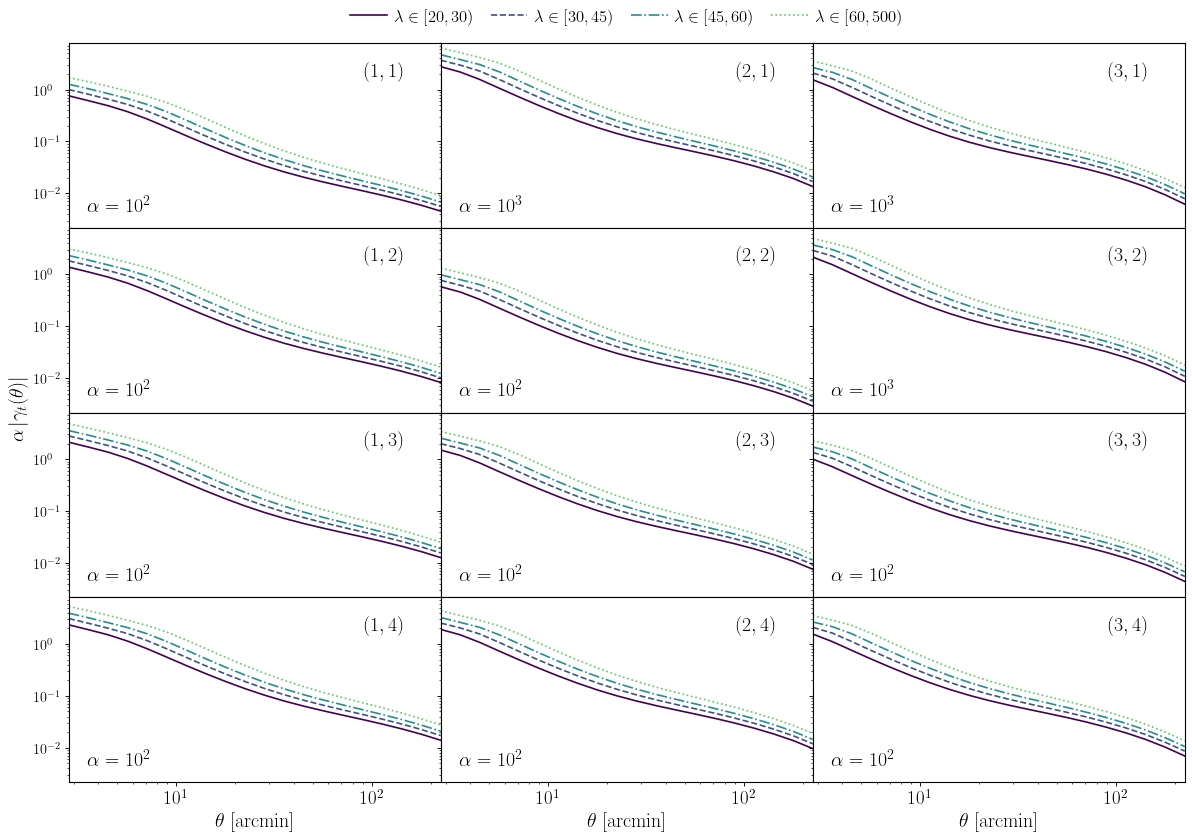

In [13]:
# gamma_t[theta, richness bin, cluster z bin, source bin]: the tangential
# shear BEFORE the Y transform, the selection bias and the shear
# calibration (the likelihood applies those on the data vector).
# Layout of the cluster lensing plots: columns = cluster z bins, rows =
# source bins, the label in each panel is (cluster z bin, source bin);
# the richness bins are the curves of a panel. rescale = 1 multiplies
# each panel by its own power of ten (alpha) so the grid shares one y axis
theta_gammat = nw.gamma_t_cluster()
print(theta_gammat[1].shape)

pdc.plot_gammat_cluster_tomo(theta_gammat = [theta_gammat],
                             richnesslabel = richness_label,
                             cmap = "viridis",
                             linewidth = [1.5],
                             figsize = (18, 12),
                             bintextsize = 18,
                             yaxislabelsize = 18,
                             xaxislabelsize = 18,
                             yaxisticklabelsize = 13,
                             xaxisticklabelsize = 17,
                             rescale = 1,
                             ydecades = 4)

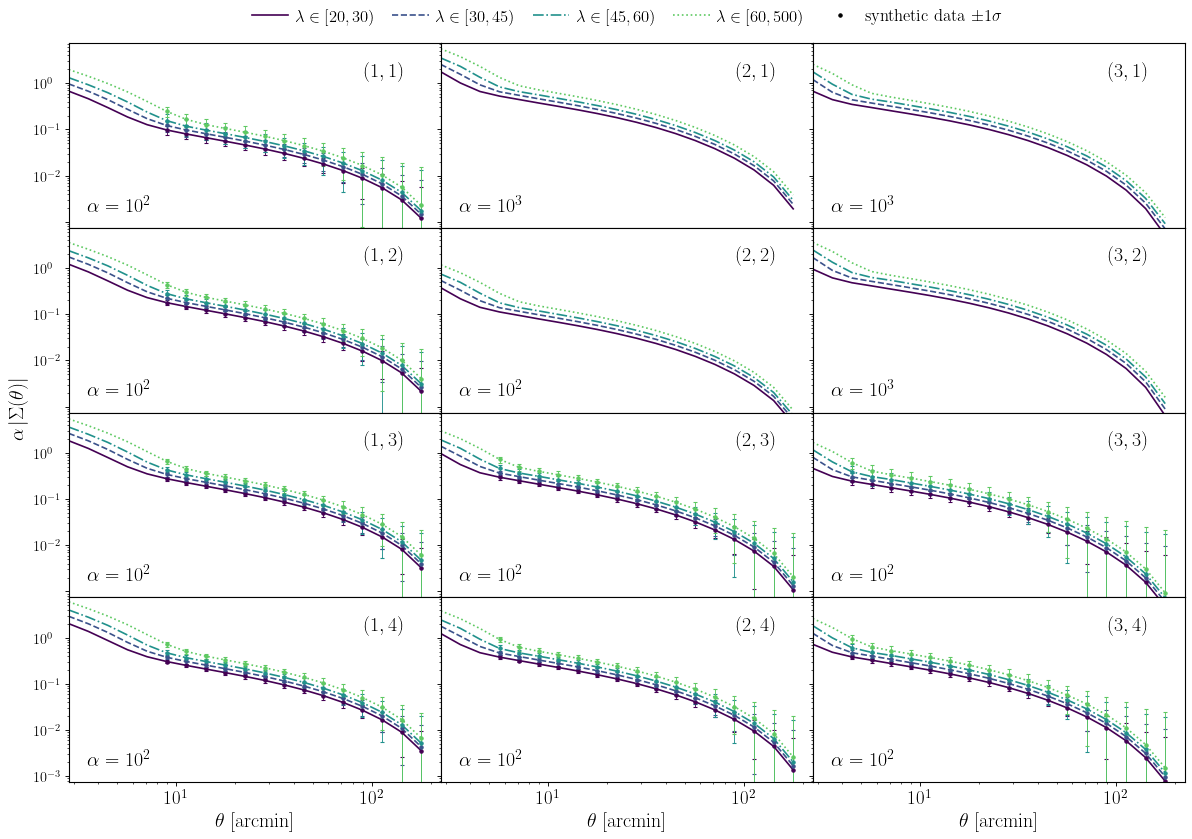

In [14]:
# What the data vector holds (the cs block): Sigma = T gamma_t, the Y
# transform of eq (15) that removes the mass enclosed below each scale,
# times the selection bias of eq (23) and the shear calibration. The last
# angular bin of Sigma is zero by construction (always masked). Points:
# the synthetic data where the scale cuts keep them (Sigma > 2 Mpc/h).
theta_sigma = nw.sigma_cluster()
theta = theta_sigma[0]

pdc.plot_sigma_cluster_tomo(theta_sigma = [theta_sigma],
                            data = (theta, data["cs"], error["cs"]),
                            datalabel = r"synthetic data $\pm 1\sigma$",
                            richnesslabel = richness_label,
                            cmap = "viridis",
                            linewidth = [1.5],
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17,
                            rescale = 1,
                            ydecades = 4)

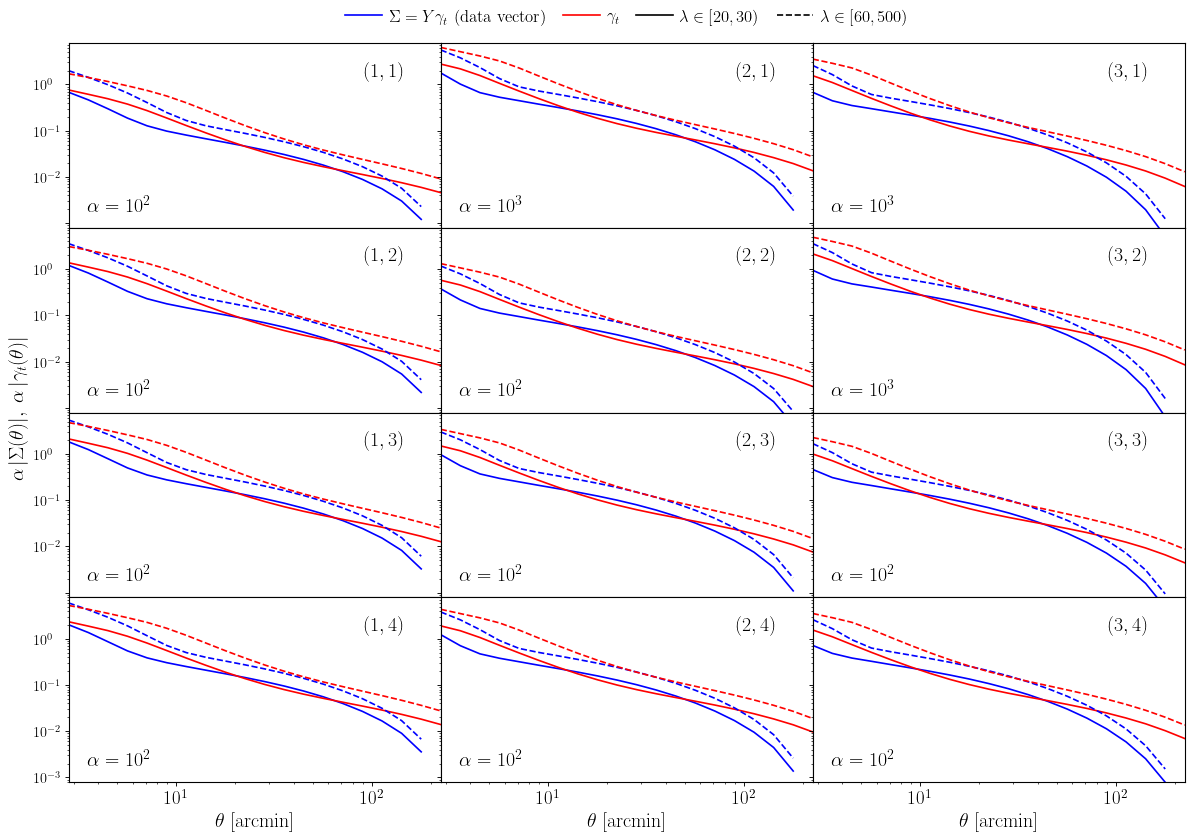

In [15]:
# Sigma against gamma_t for the lowest and the highest richness bin
# (richness counts from 0): with two entries in the list the color tells
# the entries apart and the line style the richness bins
pdc.plot_sigma_cluster_tomo(theta_sigma = [theta_sigma, theta_gammat],
                            legend = [r"$\Sigma = Y\gamma_t$ (data vector)", r"$\gamma_t$"],
                            richness = [0, nrichness-1],
                            richnesslabel = richness_label,
                            cmap = "brg",
                            linewidth = [1.5],
                            ylabel = r"$\alpha\,|\Sigma(\theta)|,\ \alpha\,|\gamma_t(\theta)|$",
                            figsize = (18, 12),
                            bintextsize = 18,
                            yaxislabelsize = 18,
                            xaxislabelsize = 18,
                            yaxisticklabelsize = 13,
                            xaxisticklabelsize = 17,
                            rescale = 1,
                            ydecades = 4)

# Cluster clustering $w_{cc}(\theta)$

(20, 4, 4, 3)


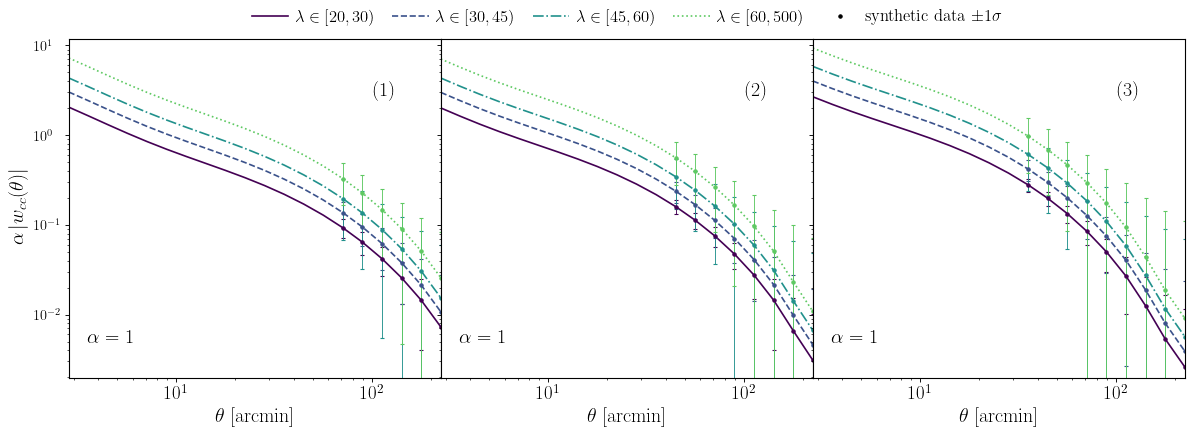

In [16]:
# w_cc[theta, richness bin 1, richness bin 2, cluster z bin]: auto z bin,
# every richness pair (symmetric). selection_bias = True multiplies by the
# selection bias squared (eq 23), as the data vector carries it. One panel
# per cluster z bin; the curves are the richness auto pairs (the default;
# pairs = [(0, 3), ...] picks any others). Points: the synthetic data
# where the scale cuts keep them (w_cc > 16 Mpc/h).
theta_wcc = nw.w_cc(selection_bias=True)
theta_wcc_nobias = nw.w_cc(selection_bias=False)
print(theta_wcc[1].shape)

pdc.plot_wcc_tomo(theta_wcc = [theta_wcc],
                  data = (theta, data["cc"], error["cc"]),
                  datalabel = r"synthetic data $\pm 1\sigma$",
                  richnesslabel = richness_label,
                  cmap = "viridis",
                  linewidth = [1.5],
                  figsize = (18, 5.5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17,
                  rescale = 1,
                  ydecades = 4)

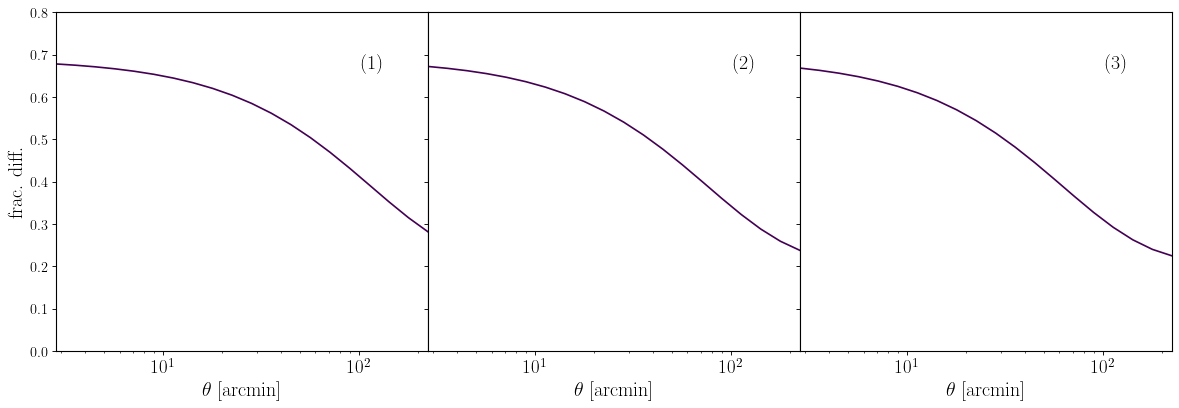

In [17]:
# What the selection bias does to w_cc: with a reference the panels show
# the fractional difference, here B(theta)^2 - 1 (ylim is the band of
# the ratio, drawn as ylim - 1). B does not depend on the richness, so
# one richness pair is enough (pairs counts the richness bins from 0)
pdc.plot_wcc_tomo(theta_wcc = [theta_wcc],
                  theta_wcc_ref = theta_wcc_nobias,
                  pairs = [(0, 0)],
                  cmap = "viridis",
                  linewidth = [1.5],
                  ylim = [1.0, 1.8],
                  figsize = (18, 5.5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17)

# Cluster x galaxy clustering $w_{cg}(\theta)$

(20, 4, 3, 6)  nonzero (cluster z bin, lens bin) pairs: [[0, 0], [1, 1], [2, 2]]


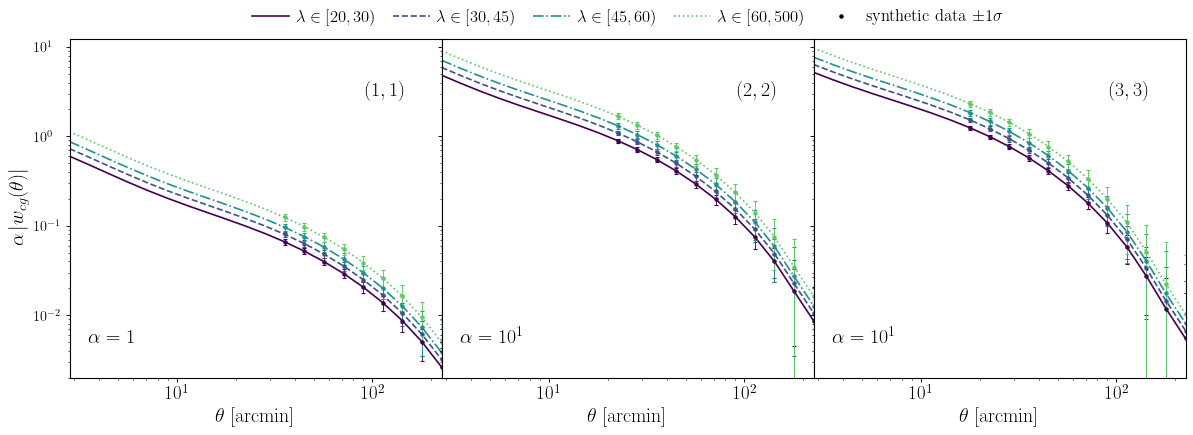

In [18]:
# w_cg[theta, richness bin, cluster z bin, lens bin]: only the (cluster z
# bin, lens bin) pairs of the dataset are filled (cg_lens_bins), the rest
# is zero, and only those pairs get a panel (the label in each panel).
# selection_bias = True multiplies by the selection bias (eq 23).
# Points: the synthetic data where the scale cuts keep them (w_cg > 8 Mpc/h).
theta_wcg = nw.w_cg(selection_bias=True)
cg_pairs = np.array(ci.get_cg_redshift_bins()).astype(int)   # row n = (cluster z bin, lens bin)
print(theta_wcg[1].shape, " nonzero (cluster z bin, lens bin) pairs:", cg_pairs.tolist())

pdc.plot_wcg_tomo(theta_wcg = [theta_wcg],
                  data = (theta, data["cg"], error["cg"]),
                  datalabel = r"synthetic data $\pm 1\sigma$",
                  richnesslabel = richness_label,
                  cmap = "viridis",
                  linewidth = [1.5],
                  figsize = (18, 5.5),
                  bintextsize = 18,
                  yaxislabelsize = 18,
                  xaxislabelsize = 18,
                  yaxisticklabelsize = 13,
                  xaxisticklabelsize = 17,
                  rescale = 1,
                  ydecades = 4)

# Fourier space: $C_\ell^{cs}$, $C_\ell^{cc}$, $C_\ell^{cg}$ (Limber)

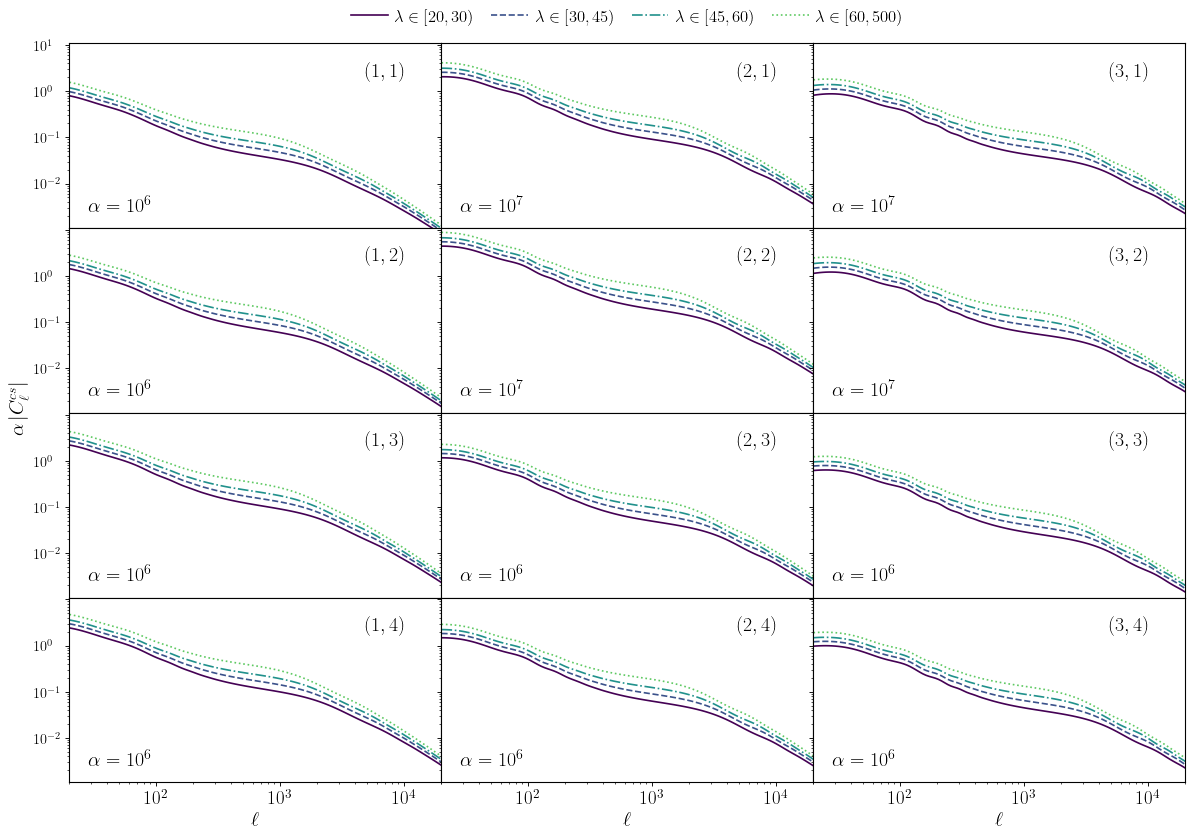

In [19]:
# The spectra behind the three real-space statistics:
# C_cs[ell, richness, cluster z, source], C_cc[ell, richness 1, richness 2,
# cluster z], C_cg[ell, richness, cluster z, lens]
ell = np.logspace(np.log10(20.0), np.log10(20000.0), 120)
C_cs = nw.C_cs_tomo_limber(ell)
C_cc = nw.C_cc_tomo_limber(ell)
C_cg = nw.C_cg_tomo_limber(ell)

pdc.plot_C_cs_tomo_limber(ell = ell,
                          C_cs = [C_cs],
                          richnesslabel = richness_label,
                          cmap = "viridis",
                          linewidth = [1.5],
                          lmin = ell[0],
                          lmax = ell[-1],
                          figsize = (18, 12),
                          bintextsize = 18,
                          yaxislabelsize = 18,
                          xaxislabelsize = 18,
                          yaxisticklabelsize = 13,
                          xaxisticklabelsize = 17,
                          rescale = 1,
                          ydecades = 4)

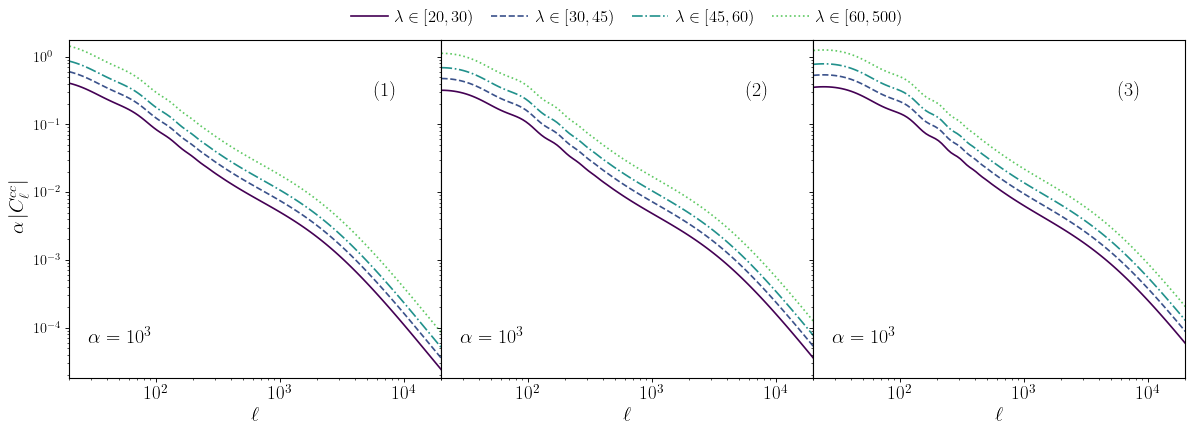

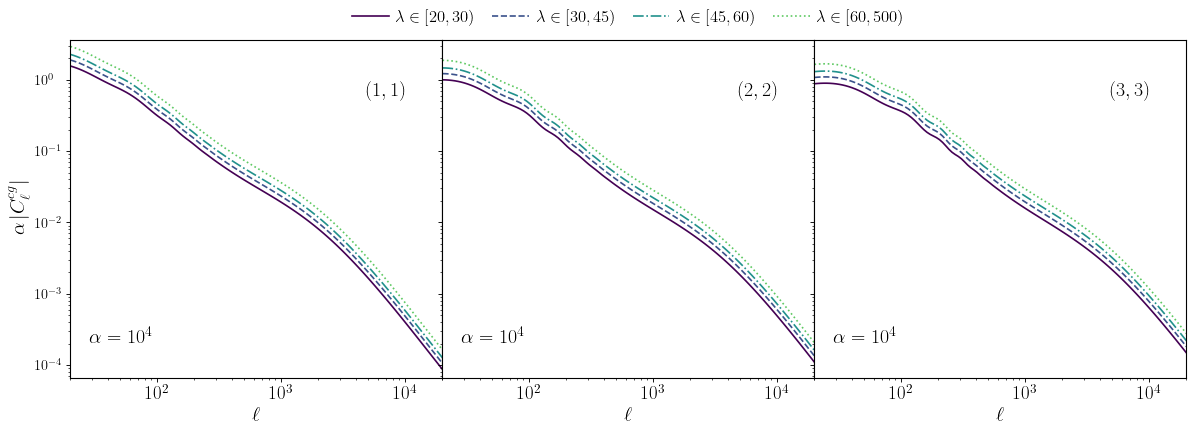

In [20]:
pdc.plot_C_cc_tomo_limber(ell = ell,
                          C_cc = [C_cc],
                          richnesslabel = richness_label,
                          cmap = "viridis",
                          linewidth = [1.5],
                          lmin = ell[0],
                          lmax = ell[-1],
                          figsize = (18, 5.5),
                          bintextsize = 18,
                          yaxislabelsize = 18,
                          xaxislabelsize = 18,
                          yaxisticklabelsize = 13,
                          xaxisticklabelsize = 17,
                          rescale = 1,
                          ydecades = 5)
pdc.plot_C_cg_tomo_limber(ell = ell,
                          C_cg = [C_cg],
                          richnesslabel = richness_label,
                          cmap = "viridis",
                          linewidth = [1.5],
                          lmin = ell[0],
                          lmax = ell[-1],
                          figsize = (18, 5.5),
                          bintextsize = 18,
                          yaxislabelsize = 18,
                          xaxislabelsize = 18,
                          yaxisticklabelsize = 13,
                          xaxisticklabelsize = 17,
                          rescale = 1,
                          ydecades = 5)

# Let's plot how the mass-observable relation affects the counts and $\gamma_t(\theta)$

In [21]:
# Every wrapper takes the cosmology and the nuisance vectors as keyword
# arguments. MOR = [ln lambda_0, A_lambda, sigma_int, B_lambda]
param = np.linspace(DES_CL_LNLAMBDA0 - 0.2, DES_CL_LNLAMBDA0 + 0.2, 5)
counts_param = []
gammat_param = []
for x in param:
    MOR = [x, DES_CL_A_LAMBDA, DES_CL_SIGMA_INT, DES_CL_B_LAMBDA]
    counts_param.append(nw.N_cluster(MOR=MOR))
    gammat_param.append(nw.gamma_t_cluster(MOR=MOR))

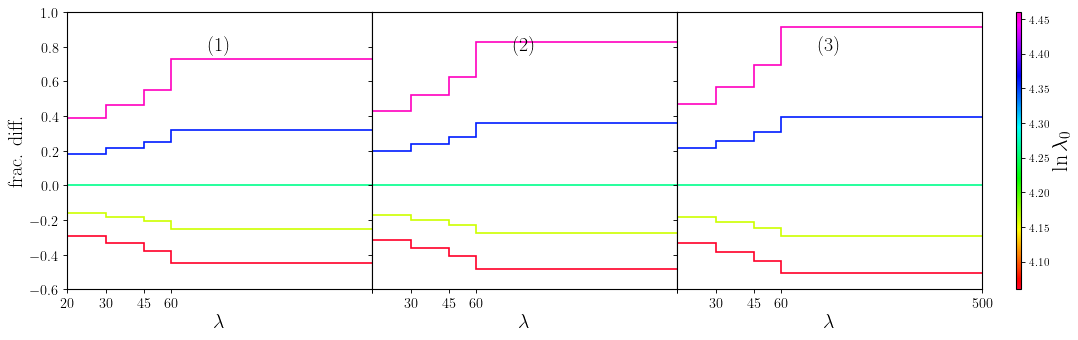

In [22]:
# Plot the ratio over the fiducial model: with a list of models, the color
# follows the parameter value (the colorbar)
pdc.plot_N_cluster(N = counts_param,
                   N_ref = counts,
                   param = param,
                   colorbarlabel = r"$\ln\lambda_0$",
                   richness_edges = richness_edges,
                   ylim = [0.4, 2.0],
                   figsize = (18, 4.5),
                   bintextpos = [0.5, 0.88],
                   bintextsize = 18,
                   yaxislabelsize = 18,
                   xaxislabelsize = 18,
                   yaxisticklabelsize = 13,
                   xaxisticklabelsize = 13)

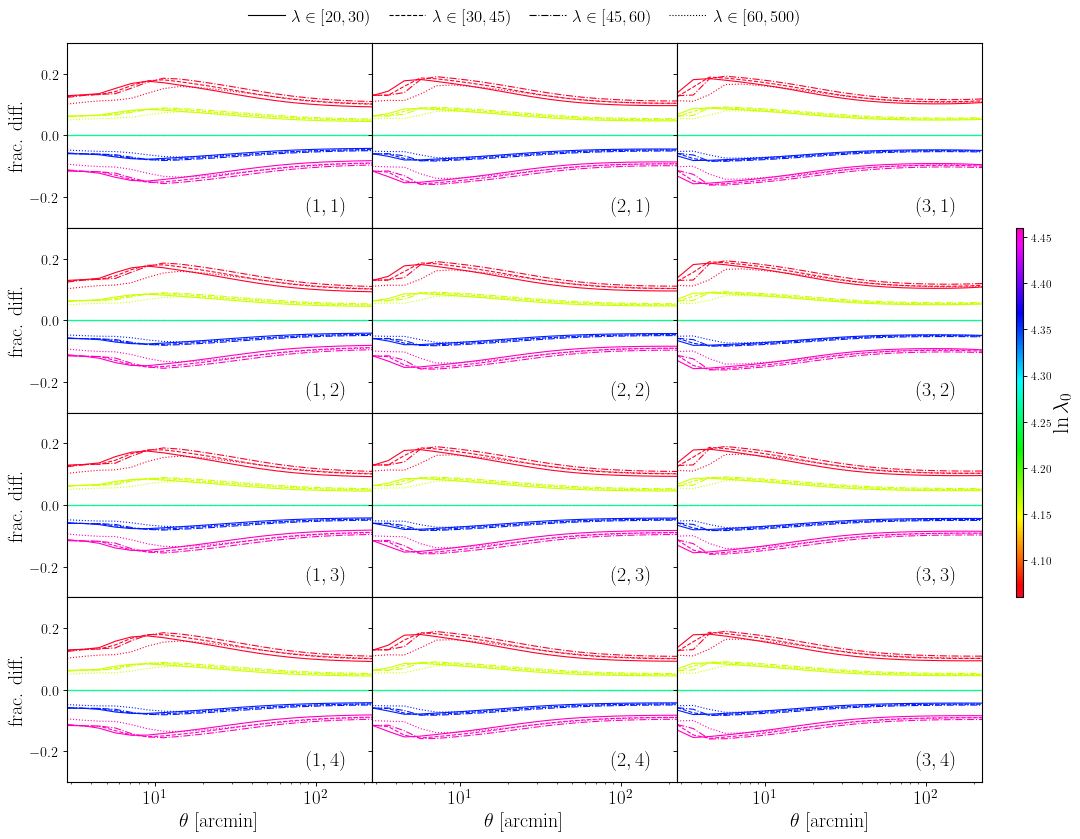

In [23]:
# gamma_t: the color is the parameter value, the line style the richness bin
pdc.plot_gammat_cluster_tomo(theta_gammat = gammat_param,
                             gammat_ref = theta_gammat,
                             param = param,
                             colorbarlabel = r"$\ln\lambda_0$",
                             richnesslabel = richness_label,
                             ylim = [0.7, 1.3],
                             figsize = (18, 12),
                             bintextpos = [0.85, 0.12],
                             bintextsize = 18,
                             yaxislabelsize = 18,
                             xaxislabelsize = 18,
                             yaxisticklabelsize = 13,
                             xaxisticklabelsize = 17)

# $\chi^2$ against the synthetic data vector

In [24]:
# The synthetic data vector is the likelihood's model at the fiducial point
# (scripts/make_synthetic_data.py), so chi2 is small there; it is not
# exactly zero because this notebook's CAMB run is not the cobaya one.
print(r"$\chi^2$ (fiducial) = %.3e"%nw.get_chi2())
print(r"$\chi^2$ (omegam = 0.31) = %.3f"%nw.get_chi2(omegam=0.31))
print(r"$\chi^2$ (ln lambda_0 + 0.05) = %.3f"%nw.get_chi2(MOR=[DES_CL_LNLAMBDA0 + 0.05, DES_CL_A_LAMBDA, DES_CL_SIGMA_INT, DES_CL_B_LAMBDA]))

$\chi^2$ (fiducial) = 1.334e-05


$\chi^2$ (omegam = 0.31) = 219.000


$\chi^2$ (ln lambda_0 + 0.05) = 86.574
